# 03: Bayesian Optimization Landscape
**Objective:** Parse the hyperopt `Trials` checkpoint files (`.pkl`) to visualize how the Tree-structured Parzen Estimator (TPE) navigated the 8-dimensional hyperparameter spaces to find the global mathematical minimums for our base models.

In [55]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set SOTA visual aesthetic
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)

def parse_trials(pkl_path, choice_mappings=None):
    """
    Extracts hyperparameters and validation loss from a hyperopt Trials pickle file.
    Maps hp.choice indices back to their actual string/int values.
    """
    if not os.path.exists(pkl_path):
        print(f"Waiting for {pkl_path} to be generated...")
        return pd.DataFrame()
        
    with open(pkl_path, 'rb') as f:
        trials = pickle.load(f)
        
    data = []
    for t in trials.trials:
        if t['result']['status'] == 'ok':
            row = {'iteration': t['tid'], 'val_mae': t['result']['loss']}
            
            # Extract hyperparameters
            for param_name, param_value_list in t['misc']['vals'].items():
                val = param_value_list[0] if len(param_value_list) > 0 else np.nan
                
                # hyperopt stores hp.choice as the index. We must map it back.
                if choice_mappings and param_name in choice_mappings and not pd.isna(val):
                    val = choice_mappings[param_name][int(val)]
                    
                row[param_name] = val
            data.append(row)
            
    df = pd.DataFrame(data).sort_values('iteration')
    return df

# Define the hp.choice mappings from optimize.py so our plots show real values, not indices
CHOICE_MAPPINGS = {
    'lgb_n_est': [500, 1000, 1500],
    'xgb_n_est': [500, 1000, 1500],
    'cat_n_est': [500, 1000, 1500],
    'rf_n_est': [300, 500, 1000],
    'rf_features': ['sqrt', 'log2', None],
    'dnn_bs': [32, 64, 128]
}

TRIALS_DIR = '../data/outputs/trials/'

## 1. LightGBM Optimization Trajectory
Let's see if the TPE algorithm successfully converged, or if it was still randomly exploring when it hit `max_evals`.

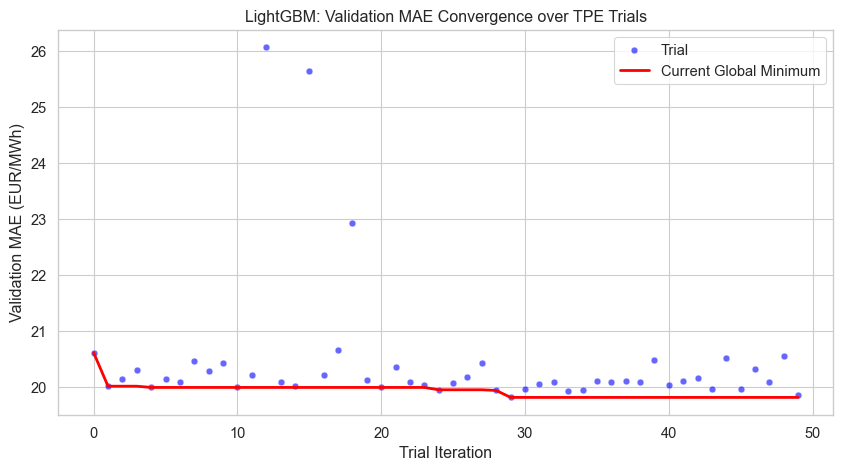

In [56]:
lgb_df = parse_trials(os.path.join(TRIALS_DIR, 'lgb_trials.pkl'), CHOICE_MAPPINGS)

if not lgb_df.empty:
    # 1. Convergence Plot
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=lgb_df, x='iteration', y='val_mae', color='blue', alpha=0.6, label='Trial')
    
    # Plot a rolling minimum line to show the "best so far"
    lgb_df['best_so_far'] = lgb_df['val_mae'].cummin()
    sns.lineplot(data=lgb_df, x='iteration', y='best_so_far', color='red', linewidth=2, label='Current Global Minimum')
    
    plt.title('LightGBM: Validation MAE Convergence over TPE Trials')
    plt.ylabel('Validation MAE (EUR/MWh)')
    plt.xlabel('Trial Iteration')
    plt.legend()
    plt.show()

## 2. Dynamic Optimization Landscapes
This engine dynamically reads the trial logs for any evaluated architecture and plots its convergence trajectory alongside its most critical hyperparameter interactions (Learning Rate vs. Complexity).

--- Visualizing LightGBM (50 trials) ---


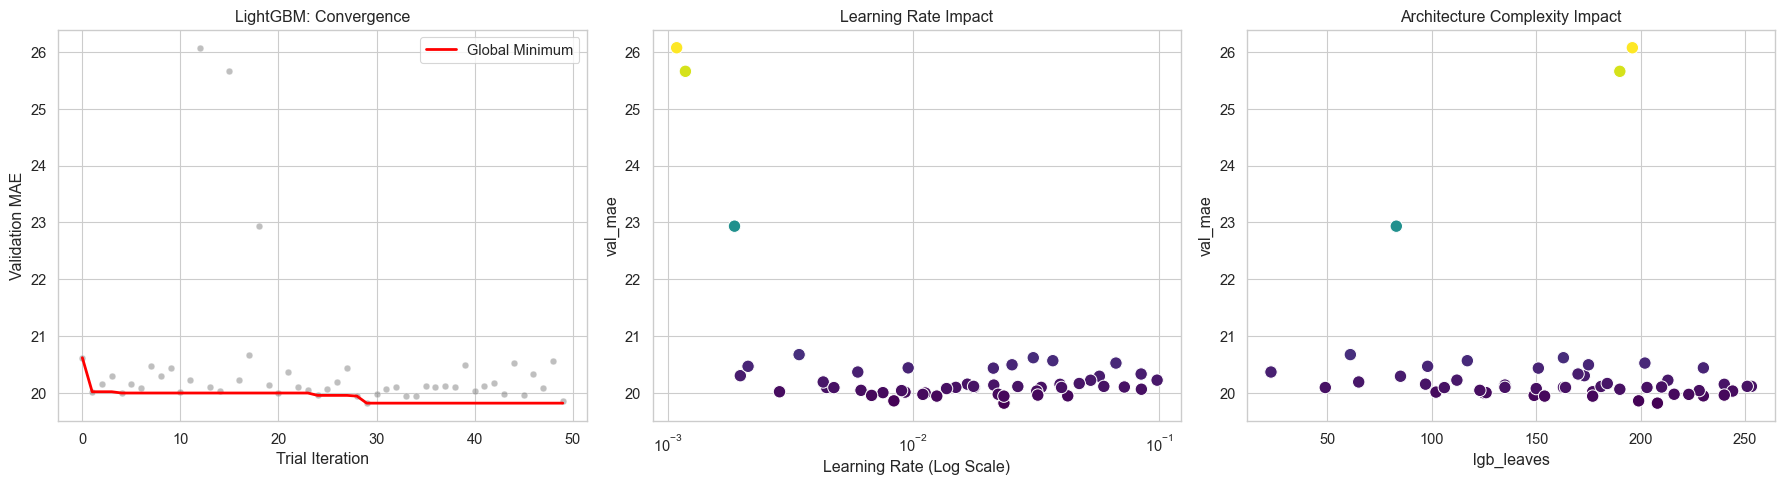

--- Visualizing XGBoost (50 trials) ---


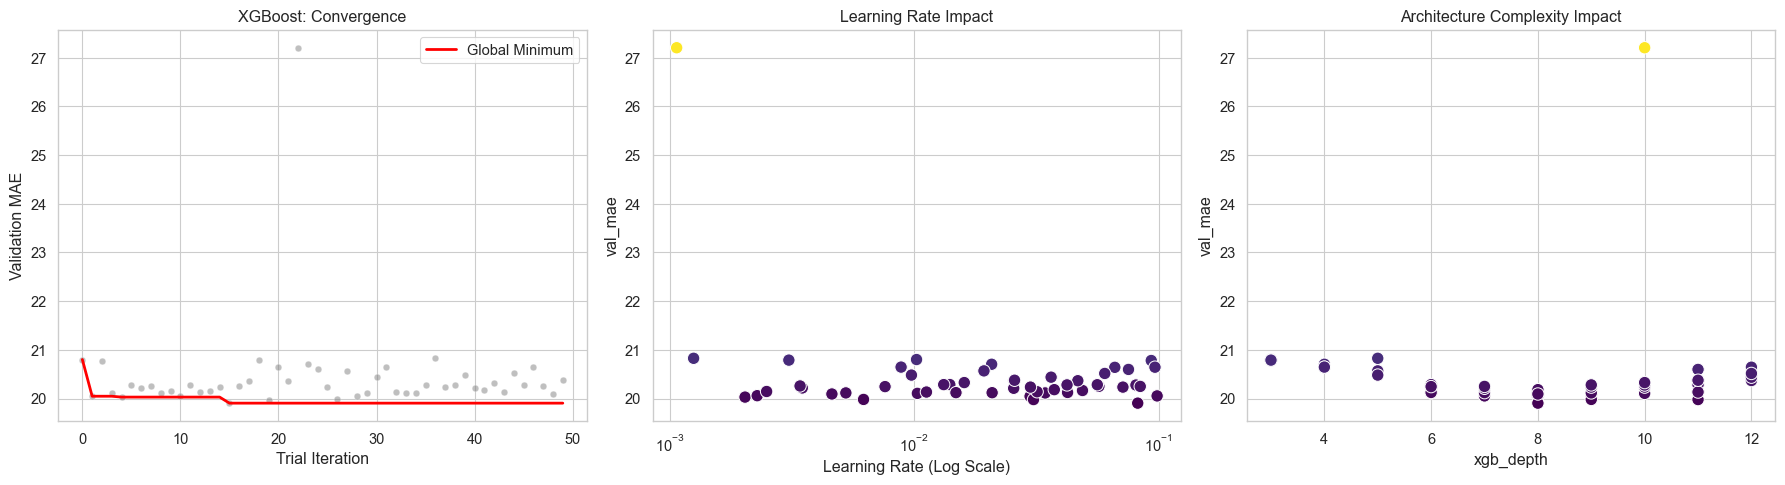

--- Visualizing CatBoost (50 trials) ---


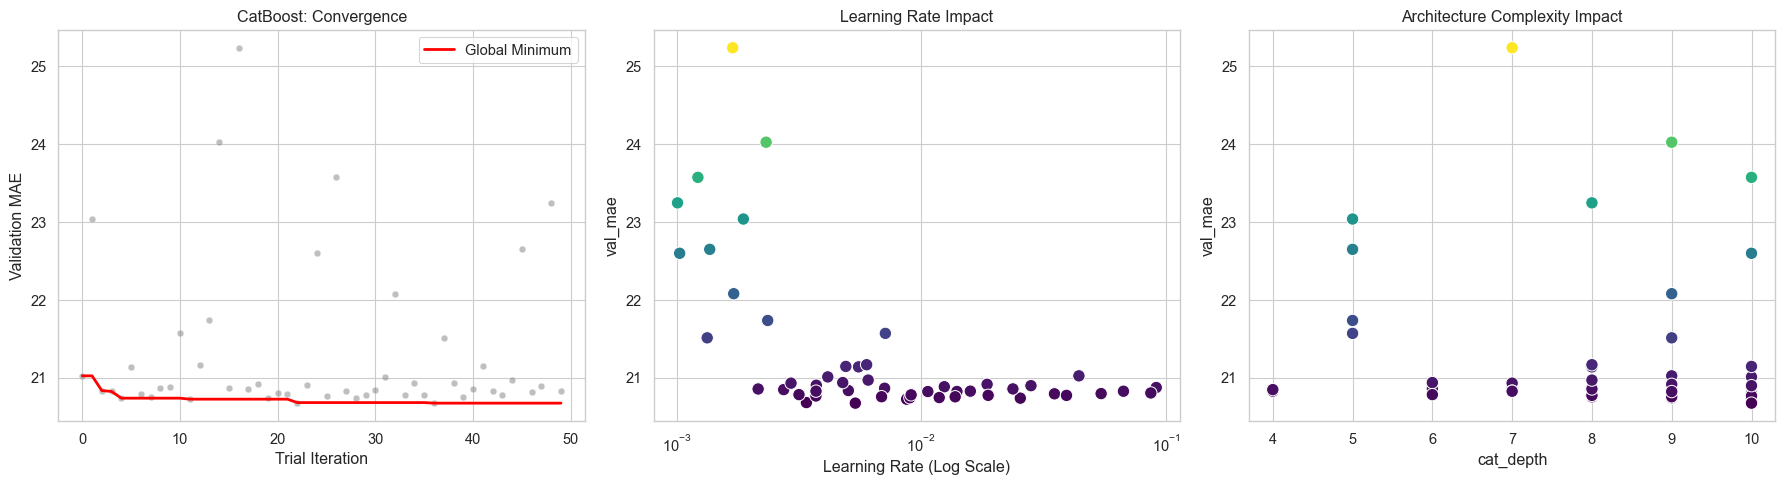

--- Visualizing PyTorch DNN (50 trials) ---


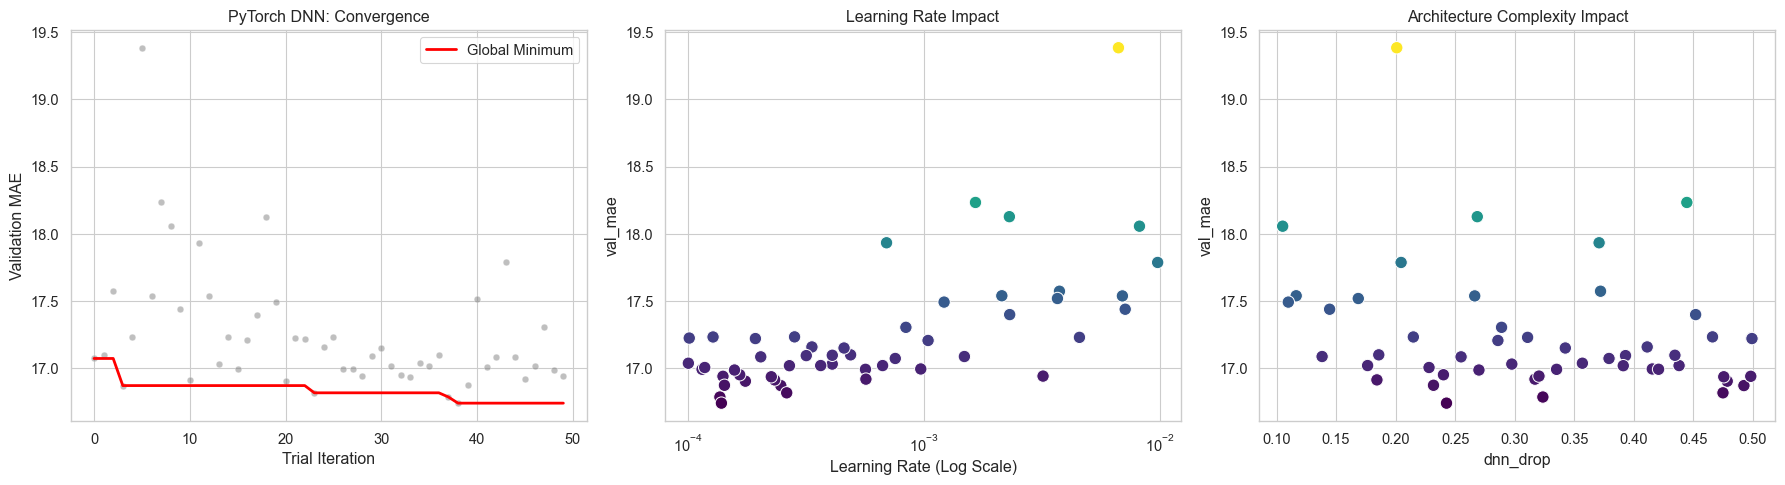

--- Visualizing RandomForest (50 trials) ---


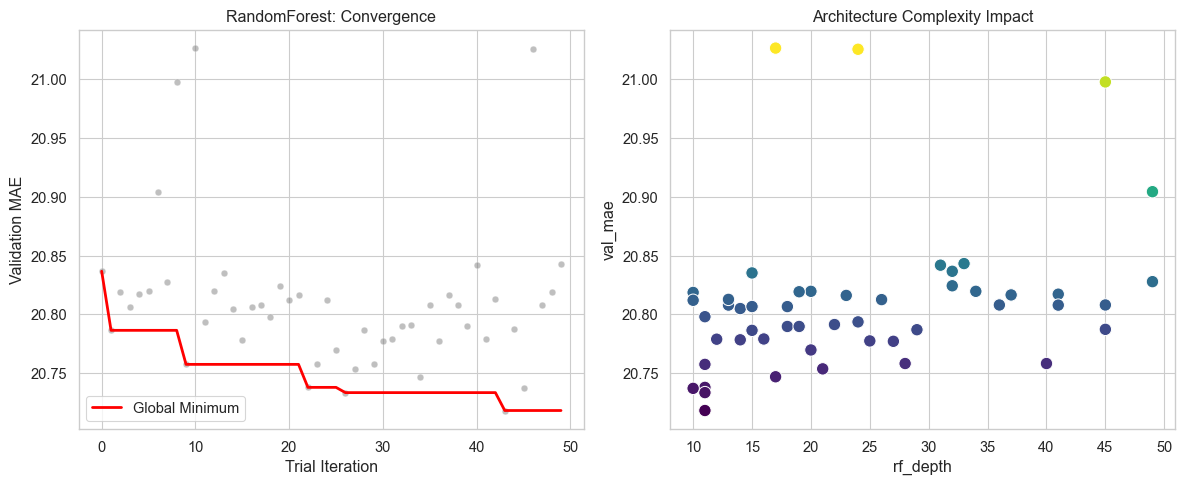

In [57]:
# Map the specific hyperparameter names used in our TPE search spaces
MODEL_CONFIGS = {
    'LightGBM':    {'file': 'lgb_trials.pkl', 'lr': 'lgb_lr', 'complexity': 'lgb_leaves', 'log_lr': True},
    'XGBoost':     {'file': 'xgb_trials.pkl', 'lr': 'xgb_lr', 'complexity': 'xgb_depth',  'log_lr': True},
    'CatBoost':    {'file': 'cat_trials.pkl', 'lr': 'cat_lr', 'complexity': 'cat_depth',  'log_lr': True},
    'PyTorch DNN': {'file': 'dnn_trials.pkl', 'lr': 'dnn_lr', 'complexity': 'dnn_drop',   'log_lr': True},
    'RandomForest':{'file': 'rf_trials.pkl',  'lr': None,     'complexity': 'rf_depth',   'log_lr': False}
}

def plot_model_landscape(model_name, config):
    filepath = os.path.join(TRIALS_DIR, config['file'])
    df = parse_trials(filepath, CHOICE_MAPPINGS)
    
    if df.empty:
        print(f"[{model_name}] No trial data found yet.")
        return
        
    print(f"--- Visualizing {model_name} ({len(df)} trials) ---")
    
    # Setup the plot grid (1 row, up to 3 columns depending on available params)
    cols = 1
    if config['lr'] in df.columns: cols += 1
    if config['complexity'] in df.columns: cols += 1
        
    fig, axes = plt.subplots(1, cols, figsize=(6 * cols, 5))
    if cols == 1: axes = [axes] # Ensure iterable
    
    ax_idx = 0
    
    # 1. Convergence Plot (Always Plotted)
    df['best_so_far'] = df['val_mae'].cummin()
    sns.scatterplot(data=df, x='iteration', y='val_mae', color='gray', alpha=0.5, ax=axes[ax_idx])
    sns.lineplot(data=df, x='iteration', y='best_so_far', color='red', linewidth=2, label='Global Minimum', ax=axes[ax_idx])
    axes[ax_idx].set_title(f'{model_name}: Convergence')
    axes[ax_idx].set_ylabel('Validation MAE')
    axes[ax_idx].set_xlabel('Trial Iteration')
    ax_idx += 1
    
    # 2. Learning Rate Plot (If applicable)
    if config['lr'] in df.columns:
        sns.scatterplot(data=df, x=config['lr'], y='val_mae', hue='val_mae', palette='viridis', s=80, legend=False, ax=axes[ax_idx])
        if config['log_lr']:
            axes[ax_idx].set_xscale('log')
        axes[ax_idx].set_title(f'Learning Rate Impact')
        axes[ax_idx].set_xlabel('Learning Rate (Log Scale)' if config['log_lr'] else 'Learning Rate')
        ax_idx += 1
        
    # 3. Complexity Plot (Leaves, Depth, or Dropout)
    if config['complexity'] in df.columns:
        sns.scatterplot(data=df, x=config['complexity'], y='val_mae', hue='val_mae', palette='viridis', s=80, legend=False, ax=axes[ax_idx])
        axes[ax_idx].set_title(f'Architecture Complexity Impact')
        axes[ax_idx].set_xlabel(config['complexity'])
        
    plt.tight_layout()
    plt.show()

# Execute the engine for ALL models dynamically
for model, config in MODEL_CONFIGS.items():
    plot_model_landscape(model, config)

## 3. Deep Neural Network (PyTorch) Landscape
Neural networks are notoriously sensitive to learning rate and dropout. Let's visualize how the optimizer navigated the Adam optimizer's learning rate against the regularization dropout penalty.

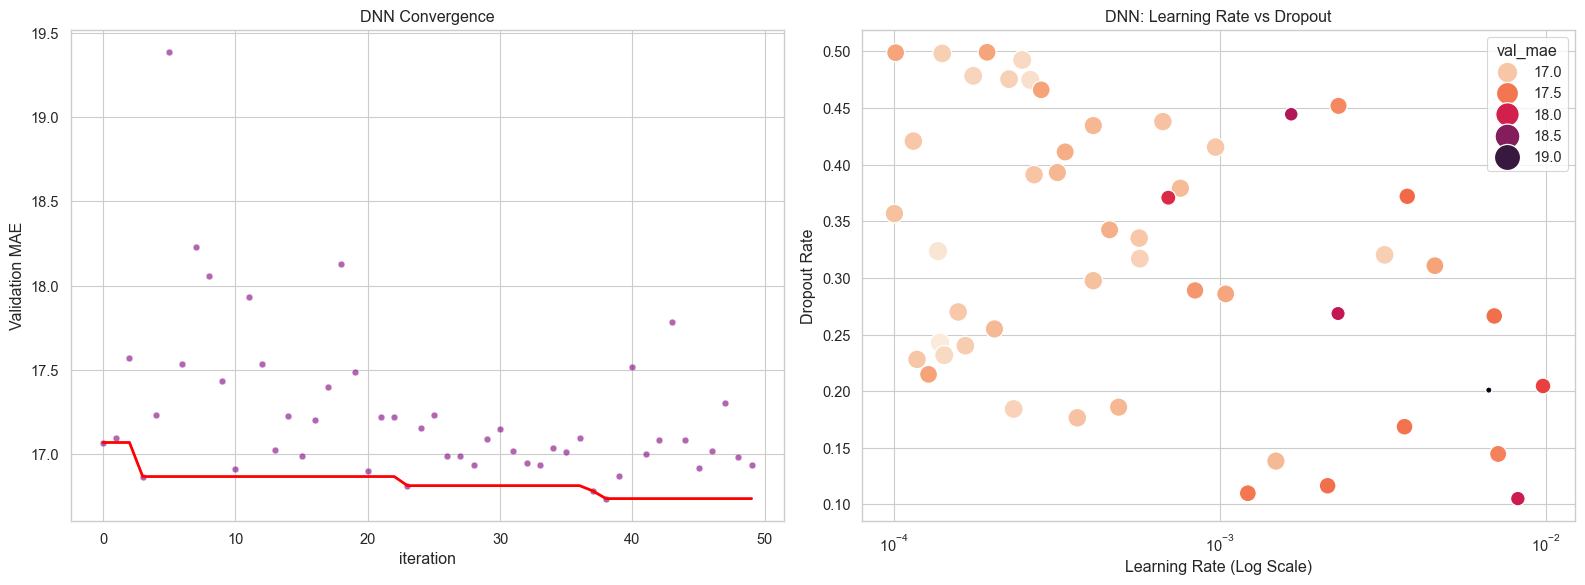

In [58]:
dnn_df = parse_trials(os.path.join(TRIALS_DIR, 'dnn_trials.pkl'), CHOICE_MAPPINGS)

if not dnn_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Convergence
    dnn_df['best_so_far'] = dnn_df['val_mae'].cummin()
    sns.scatterplot(data=dnn_df, x='iteration', y='val_mae', color='purple', alpha=0.6, ax=axes[0])
    sns.lineplot(data=dnn_df, x='iteration', y='best_so_far', color='red', linewidth=2, ax=axes[0])
    axes[0].set_title('DNN Convergence')
    axes[0].set_ylabel('Validation MAE')
    
    # LR vs Dropout Contour/Scatter
    sns.scatterplot(data=dnn_df, x='dnn_lr', y='dnn_drop', hue='val_mae', size='val_mae', sizes=(200, 20), palette='rocket_r', ax=axes[1])
    axes[1].set_xscale('log')
    axes[1].set_title('DNN: Learning Rate vs Dropout')
    axes[1].set_xlabel('Learning Rate (Log Scale)')
    axes[1].set_ylabel('Dropout Rate')
    
    plt.tight_layout()
    plt.show()

## 4. Final Base Model Showdown
Which architecture ultimately won the Point Forecasting phase before entering the Ensemble?

C:\Users\mathi\AppData\Local\Temp\ipykernel_53564\529770794.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(best_scores.keys()), y=list(best_scores.values()), palette='mako')


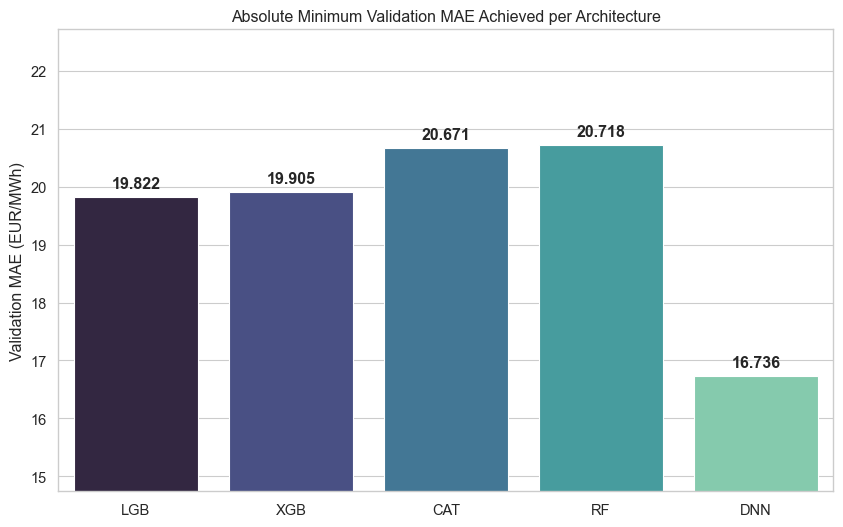

In [59]:
models = ['lgb', 'xgb', 'cat', 'rf', 'dnn']
best_scores = {}

for m in models:
    df = parse_trials(os.path.join(TRIALS_DIR, f'{m}_trials.pkl'), CHOICE_MAPPINGS)
    if not df.empty:
        best_scores[m.upper()] = df['val_mae'].min()

if best_scores:
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=list(best_scores.keys()), y=list(best_scores.values()), palette='mako')
    
    # Annotate bars
    for i, v in enumerate(best_scores.values()):
        ax.text(i, v + 0.1, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
        
    plt.title('Absolute Minimum Validation MAE Achieved per Architecture')
    plt.ylabel('Validation MAE (EUR/MWh)')
    plt.ylim(min(best_scores.values()) - 2, max(best_scores.values()) + 2) # Zoom in to see the margins
    plt.show()